# Fulfillment Analysis

## Objective

The purpose of this analysis is to evaluate fulfillment operations and understand:

- Fulfillment method distribution
- Shipping service level performance
- Courier status distribution
- Cancellation behavior
- Operational efficiency insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/cleaned_amazon_sales.csv')

In [3]:
df['Fulfilment'].value_counts()

,count
Fulfilment,
Amazon,89575
Merchant,39200


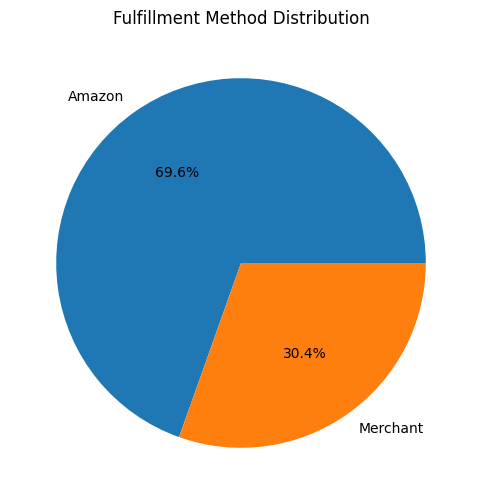

In [4]:
plt.figure(figsize=(8,6))

df['Fulfilment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Fulfillment Method Distribution')

plt.show()

## Fulfillment Insights

- Majority of orders are fulfilled by Amazon.
- Merchant fulfilled orders account for 30.4%.
- Fulfillment operations appear to rely primarily on ______.

In [5]:
df['ship-service-level'].value_counts()

,count
ship-service-level,
Expedited,88493
Standard,40282


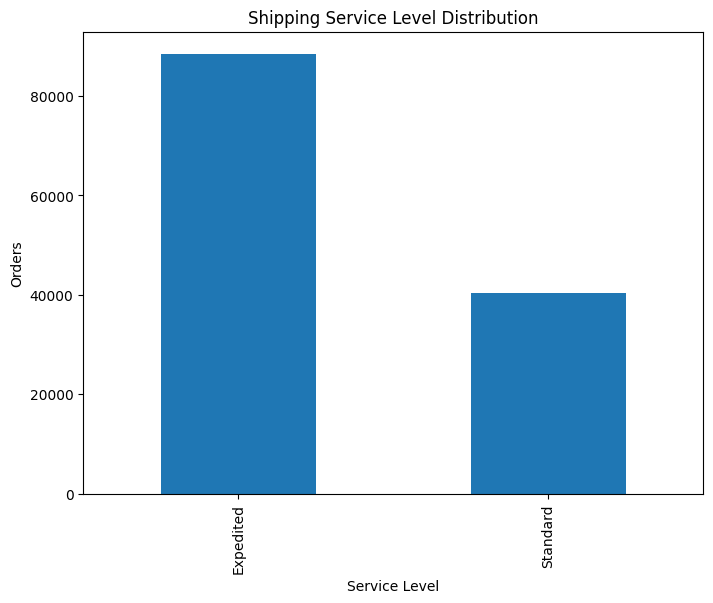

In [6]:
plt.figure(figsize=(8,6))

df['ship-service-level'].value_counts().plot(
    kind='bar'
)

plt.title('Shipping Service Level Distribution')
plt.xlabel('Service Level')
plt.ylabel('Orders')

plt.show()

## Shipping Insights

- Most customers selected Expedited shipping.
- Expedited shipping accounts for 68.71% of orders.
- Customers appear to prioritize Expedited.

In [7]:
df['Courier Status'].value_counts()

,count
Courier Status,
Shipped,109315
On the Way,6860
Unshipped,6673
Cancelled,5927


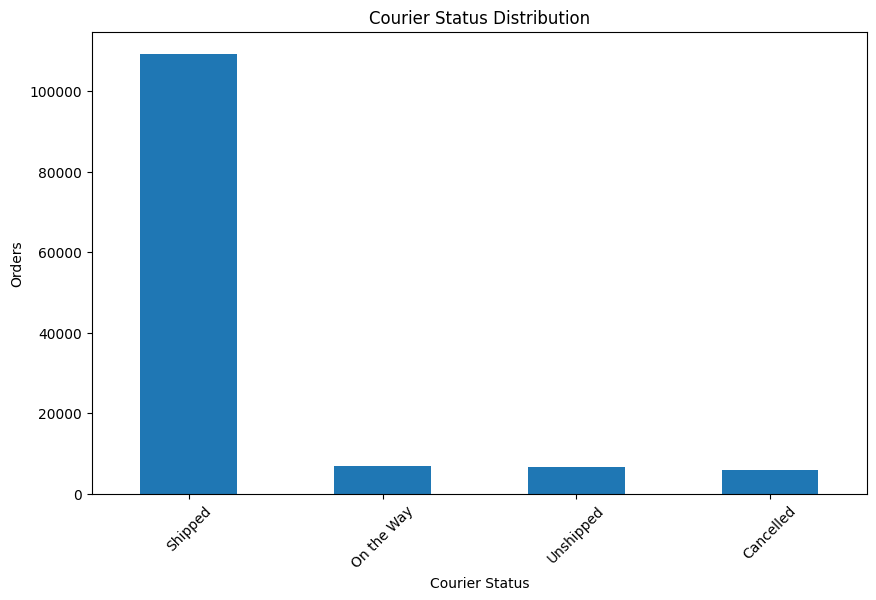

In [8]:
plt.figure(figsize=(10,6))

df['Courier Status'].value_counts().plot(
    kind='bar'
)

plt.title('Courier Status Distribution')
plt.xlabel('Courier Status')
plt.ylabel('Orders')

plt.xticks(rotation=45)

plt.show()

## Courier Insights

- Most shipments are currently in Shipped status.
- Operational delays appear in the Cancelled status.

In [9]:
cancelled = df[
    df['Status'].str.contains(
        'Cancelled',
        case=False,
        na=False
    )
]

In [10]:
cancelled.shape

(18304, 19)

In [11]:
cancel_rate = (
    len(cancelled) /
    len(df)
) * 100

print(cancel_rate)

14.21393904096292


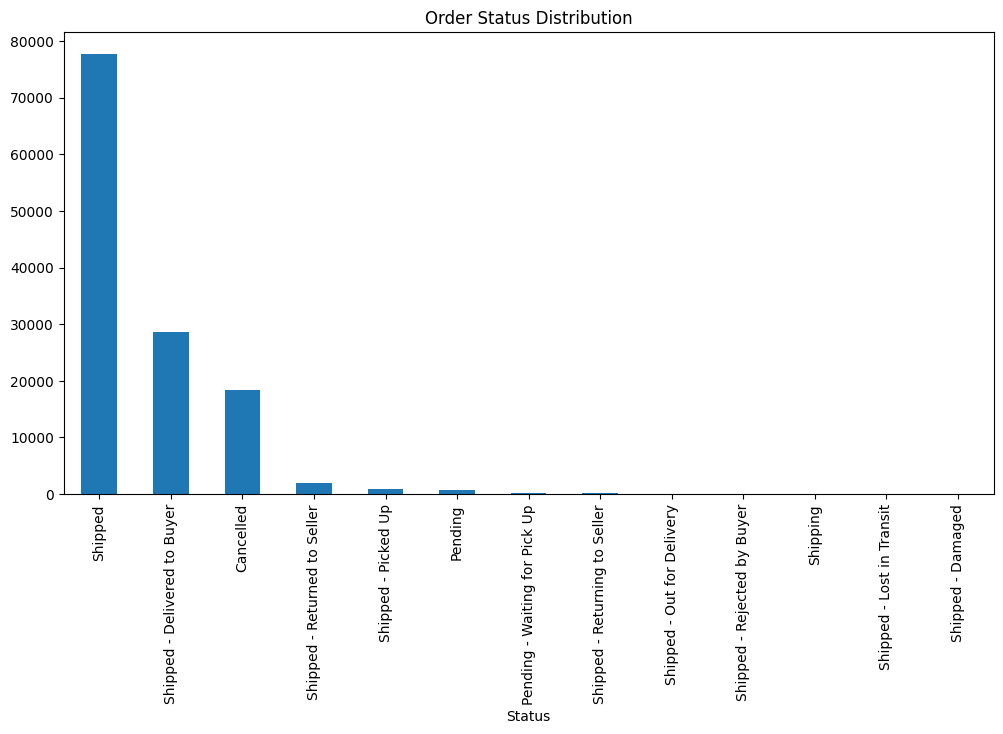

In [12]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(12,6))

status_counts.plot(kind='bar')

plt.title('Order Status Distribution')

plt.show()

## Cancellation Insights

- Cancellation Rate: 14.21%
- Approximately 1 out of every 7 orders is cancelled.
- Reducing cancellations could significantly improve revenue.

In [13]:
pd.crosstab(
    df['Fulfilment'],
    df['Status']
)

Status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
Fulfilment,,,,,,,,,,,,,
Amazon,11455,415,0,77697,0,0,0,0,0,0,0,0,8
Merchant,6849,243,281,0,1,28708,5,35,973,11,1949,145,0


In [14]:
pd.crosstab(
    df['Fulfilment'],
    df['Status']
)['Cancelled']

,Cancelled
Fulfilment,
Amazon,11455
Merchant,6849


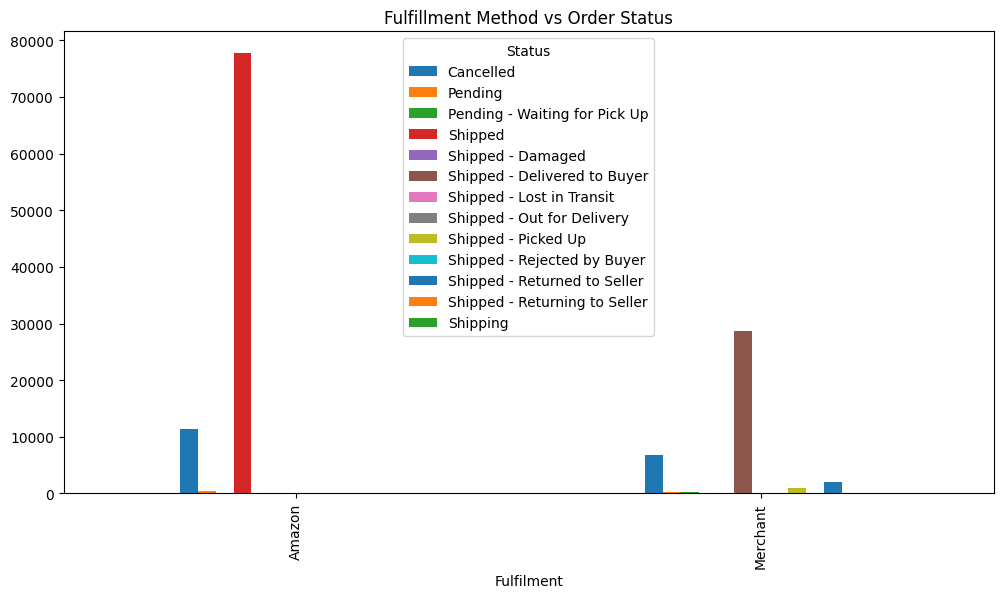

In [15]:
cancel_by_fulfillment = pd.crosstab(
    df['Fulfilment'],
    df['Status']
)

cancel_by_fulfillment.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    'Fulfillment Method vs Order Status'
)

plt.show()

# Business Recommendations

1. Increase use of the fulfillment method with lower cancellation rates.
2. Monitor merchant fulfillment performance.
3. Encourage efficient shipping methods.
4. Investigate reasons for cancelled orders.
5. Improve order tracking and logistics visibility.

# Key Findings

## Fulfillment Performance

1. Dominant Fulfillment Method: Amazon
2. Most Common Shipping Service: Expedited
3. Cancellation Rate: 14.21%
4. Most Common Courier Status: Shipped
5. Better Performing Fulfillment Method: Amazon

## Conclusion

The fulfillment process is largely dependent on Amazon fulfillment, with Expedited shipping being the preferred customer choice. Reducing cancellations and improving operational efficiency can further enhance customer satisfaction and revenue performance.